# Customer Behavior Analysis

## Internship Project

### Objective

The objective of this project is to analyze customer purchasing behavior using Python. The analysis includes data cleaning, feature engineering, exploratory data analysis (EDA), and customer segmentation using RFM (Recency, Frequency, Monetary) analysis. The findings will help identify customer groups, purchasing patterns, and business opportunities for improving customer engagement.

In [1]:
# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

# Improve graph appearance
sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


# 1. Load Dataset

The dataset is loaded using the Pandas library.

In [2]:
# Load dataset

df = pd.read_csv("ecommerce_customer_data_large.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


## Preview of Dataset

In [3]:
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0


## Dataset Information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202618 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


## Number of Rows and Columns

In [5]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 250000
Columns : 13


## Column Names

In [6]:
print(df.columns)

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='object')


## Missing Values

In [7]:
df.isnull().sum()

Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47382
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64

## Duplicate Rows

In [8]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


# 2. Data Cleaning

Data cleaning is an important step before analysis. It helps improve data quality by handling missing values, removing duplicate information, and converting columns into appropriate data types.

In [9]:
# Check missing values

df.isnull().sum()

Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47382
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64

### Observation

The dataset contains missing values only in the **Returns** column. All other columns are complete.

In [10]:
# Fill missing values in Returns with 0

df["Returns"] = df["Returns"].fillna(0)

In [11]:
df.isnull().sum()

Customer ID              0
Purchase Date            0
Product Category         0
Product Price            0
Quantity                 0
Total Purchase Amount    0
Payment Method           0
Customer Age             0
Returns                  0
Customer Name            0
Age                      0
Gender                   0
Churn                    0
dtype: int64

In [12]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


### Observation

No duplicate rows were found in the dataset.

In [13]:
# Convert Purchase Date to datetime format

df["Purchase Date"] = pd.to_datetime(df["Purchase Date"])

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Customer ID            250000 non-null  int64         
 1   Purchase Date          250000 non-null  datetime64[ns]
 2   Product Category       250000 non-null  object        
 3   Product Price          250000 non-null  int64         
 4   Quantity               250000 non-null  int64         
 5   Total Purchase Amount  250000 non-null  int64         
 6   Payment Method         250000 non-null  object        
 7   Customer Age           250000 non-null  int64         
 8   Returns                250000 non-null  float64       
 9   Customer Name          250000 non-null  object        
 10  Age                    250000 non-null  int64         
 11  Gender                 250000 non-null  object        
 12  Churn                  250000 non-null  int6

In [15]:
print(df.columns)

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='object')


In [16]:
# Remove duplicate age column

df.drop("Customer Age", axis=1, inplace=True)

In [17]:
print(df.columns)

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Returns',
       'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='object')


# 3. Feature Engineering

Feature engineering creates new variables from existing data. These new features help in better understanding customer purchasing behaviour and improve analysis.

In [18]:
df["Purchase Year"] = df["Purchase Date"].dt.year

In [19]:
df["Purchase Month"] = df["Purchase Date"].dt.month_name()

In [20]:
df["Purchase Weekday"] = df["Purchase Date"].dt.day_name()

In [21]:
df["Age Group"] = pd.cut(
    df["Age"],
    bins=[18, 30, 45, 60, 70],
    labels=["18-30", "31-45", "46-60", "61-70"],
    include_lowest=True
)

In [22]:
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Returns,Customer Name,Age,Gender,Churn,Purchase Year,Purchase Month,Purchase Weekday,Age Group
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,1.0,John Rivera,31,Female,0,2023,May,Wednesday,31-45
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,1.0,John Rivera,31,Female,0,2021,May,Sunday,31-45
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,1.0,John Rivera,31,Female,0,2020,July,Monday,31-45
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,0.0,John Rivera,31,Female,0,2023,January,Tuesday,31-45
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,1.0,John Rivera,31,Female,0,2021,May,Saturday,31-45


### Observation

New features were successfully created from the purchase date and customer age. These features will be used for exploratory data analysis and customer segmentation.

# 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps understand customer purchasing behaviour by identifying trends, patterns, and relationships in the dataset through statistical summaries and visualizations.

## 4.1 Product Category Distribution

This chart shows the number of purchases made in each product category.

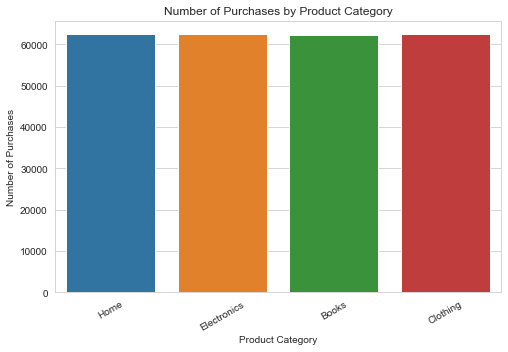

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Product Category")

plt.title("Number of Purchases by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Purchases")
plt.xticks(rotation=30)

plt.show()

**Observation:**

This chart shows how customer purchases are distributed across different product categories. Categories with more purchases are more popular among customers.

## 4.2 Revenue by Product Category

This chart shows the total revenue generated by each product category.

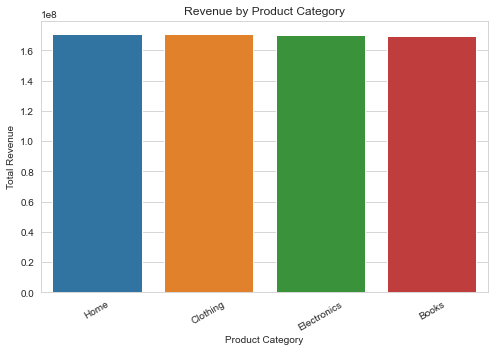

In [24]:
plt.figure(figsize=(8,5))

category_sales = df.groupby("Product Category")["Total Purchase Amount"].sum().sort_values(ascending=False)

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=30)

plt.show()

**Observation:**

Some product categories generate significantly higher revenue than others. These categories can be prioritized for marketing and promotional campaigns.

## 4.3 Payment Method Distribution

This chart shows the number of purchases made using each payment method.

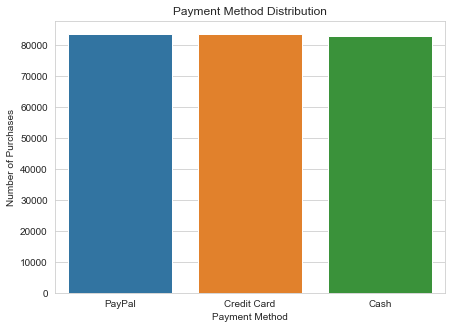

In [25]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="Payment Method")

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Number of Purchases")

plt.show()

**Observation:**

Customers use different payment methods for their purchases. Understanding payment preferences helps improve customer experience.

## 4.4 Revenue by Age Group

This chart compares the total purchase amount across different age groups.

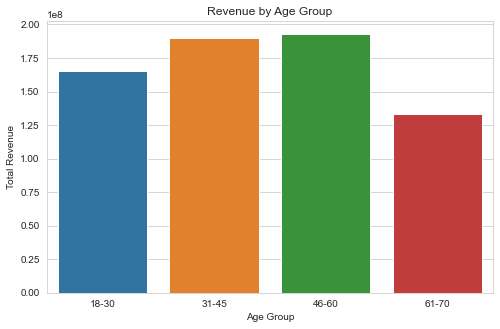

In [27]:
plt.figure(figsize=(8,5))

age_sales = df.groupby("Age Group")["Total Purchase Amount"].sum()

sns.barplot(
    x=age_sales.index.astype(str),
    y=age_sales.values
)

plt.title("Revenue by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Revenue")

plt.show()

**Observation:**

Different age groups contribute differently to total revenue. This information can help businesses create age-specific marketing campaigns.

## 4.5 Monthly Revenue Trend

This chart shows how revenue varies across different months.

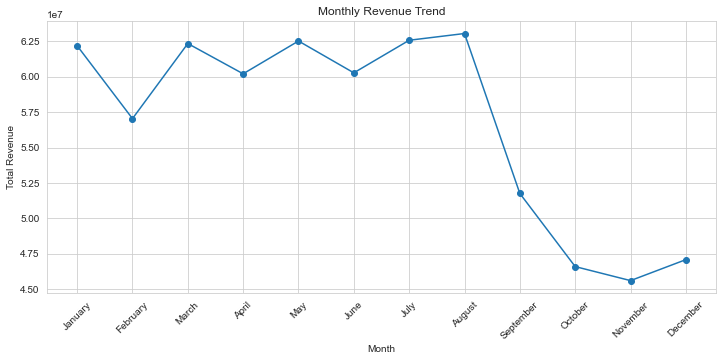

In [28]:
monthly_sales = df.groupby("Purchase Month")["Total Purchase Amount"].sum()

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_sales = monthly_sales.reindex(month_order)

plt.figure(figsize=(12,5))

plt.plot(monthly_sales.index, monthly_sales.values, marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)

plt.show()

**Observation:**

The monthly revenue trend highlights seasonal changes in customer purchases. Months with higher sales may indicate seasonal demand or successful promotions.

## 4.6 Customer Gender Distribution

This chart shows the number of male and female customers in the dataset.

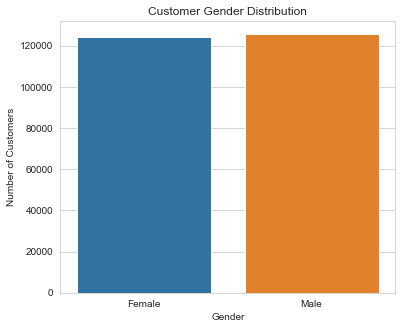

In [29]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x="Gender")

plt.title("Customer Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

**Observation:**

The dataset includes customers from both genders. Comparing customer demographics helps understand the overall customer base.

## 4.7 Correlation Heatmap

The heatmap shows the relationship between numerical variables in the dataset.

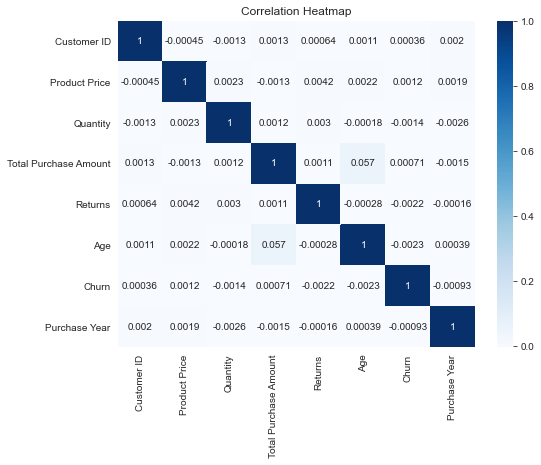

In [30]:
numeric_df = df.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(8,6))

sns.heatmap(numeric_df.corr(), annot=True, cmap="Blues")

plt.title("Correlation Heatmap")

plt.show()

**Observation:**

The heatmap helps identify relationships between numerical variables. Strong positive or negative correlations can provide useful business insights.

## 4.8 Distribution of Total Purchase Amount

This histogram shows how the total purchase amount is distributed across all customer transactions.

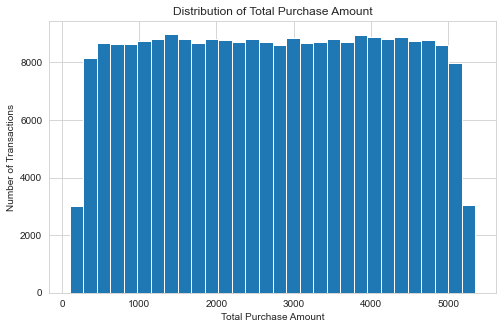

In [31]:
plt.figure(figsize=(8,5))

plt.hist(df["Total Purchase Amount"], bins=30)

plt.title("Distribution of Total Purchase Amount")
plt.xlabel("Total Purchase Amount")
plt.ylabel("Number of Transactions")

plt.show()

**Observation:**

The distribution shows how customers spend across different transactions. It helps identify whether most purchases are of low, medium, or high value and provides insight into customer spending behaviour.

# 5. Customer Segmentation using RFM Analysis

Customer segmentation helps businesses divide customers into meaningful groups based on their purchasing behaviour.

In this project, **RFM Analysis** is used.

- **Recency (R):** How recently the customer made a purchase.
- **Frequency (F):** How often the customer makes purchases.
- **Monetary (M):** How much money the customer spends.

Using these three metrics, customers can be classified into different business segments for better marketing and customer relationship management.

## 5.1 Finding the Latest Purchase Date

The latest purchase date is used as the reference date to calculate customer recency.

In [32]:
latest_date = df["Purchase Date"].max()

print("Latest Purchase Date:", latest_date)

Latest Purchase Date: 2023-09-13 18:42:49


## 5.2 Creating the RFM Table

Each customer is grouped using Customer ID and the following values are calculated:

- Recency
- Frequency
- Monetary

In [33]:
rfm = df.groupby("Customer ID").agg({

    "Purchase Date": lambda x: (latest_date - x.max()).days,

    "Customer ID": "count",

    "Total Purchase Amount": "sum"

})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
1,288,3,6290
2,72,6,16481
3,222,4,9423
4,441,5,7826
5,424,5,9769


## 5.3 Summary Statistics


In [34]:
rfm.describe()

,Recency,Frequency,Monetary
count,49661.000000,49661.000000,49661.000000
mean,261.335374,5.034131,13719.947222
std,246.804539,2.199399,6811.065854
min,0.000000,1.000000,125.000000
25%,77.000000,3.000000,8718.000000
50%,186.000000,5.000000,13008.000000
75%,370.000000,6.000000,17921.000000
max,1351.000000,17.000000,50659.000000


## 5.4 Creating the Recency Score

In [35]:
rfm["R"] = pd.qcut(

    rfm["Recency"],

    q=4,

    labels=[4,3,2,1]

)

## 5.5 Creating the Frequency Score

In [36]:
rfm["F"] = pd.qcut(

    rfm["Frequency"].rank(method="first"),

    q=4,

    labels=[1,2,3,4]

)

## 5.6 Creating the Monetary Score


In [37]:
rfm["M"] = pd.qcut(

    rfm["Monetary"],

    q=4,

    labels=[1,2,3,4]

)

## 5.7 Creating the RFM Score

In [38]:
rfm["RFM Score"] = (

    rfm["R"].astype(str)

    + rfm["F"].astype(str)

    + rfm["M"].astype(str)

)

rfm.head()

,Recency,Frequency,Monetary,R,F,M,RFM Score
Customer ID,,,,,,,
1,288,3,6290,2,1,1,211
2,72,6,16481,4,3,3,433
3,222,4,9423,2,2,2,222
4,441,5,7826,1,2,1,121
5,424,5,9769,1,2,2,122


## 5.8 Customer Segmentation

Customers are classified into different business segments based on their RFM scores.

In [39]:
def customer_segment(row):

    r = int(row["R"])
    f = int(row["F"])
    m = int(row["M"])

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    elif r >= 3 and f >= 3:
        return "Loyal Customers"

    elif r >= 3 and m >= 3:
        return "Potential Loyalists"

    elif r <= 2 and f >= 3:
        return "At Risk"

    elif r == 1 and f <= 2:
        return "Lost Customers"

    elif m >= 4:
        return "Big Spenders"

    elif f >= 4:
        return "Frequent Buyers"

    else:
        return "Regular Customers"

In [40]:
rfm["Segment"] = rfm.apply(customer_segment, axis=1)

rfm.head()

,Recency,Frequency,Monetary,R,F,M,RFM Score,Segment
Customer ID,,,,,,,,
1,288,3,6290,2,1,1,211,Regular Customers
2,72,6,16481,4,3,3,433,Loyal Customers
3,222,4,9423,2,2,2,222,Regular Customers
4,441,5,7826,1,2,1,121,Lost Customers
5,424,5,9769,1,2,2,122,Lost Customers


## 5.9 Number of Customers in Each Segment

In [41]:
rfm["Segment"].value_counts()

Regular Customers      13531
Loyal Customers        11939
At Risk                 9371
Lost Customers          9249
Champions               3520
Potential Loyalists     1962
Big Spenders              89
Name: Segment, dtype: int64

## 5.10 Customer Segment Distribution

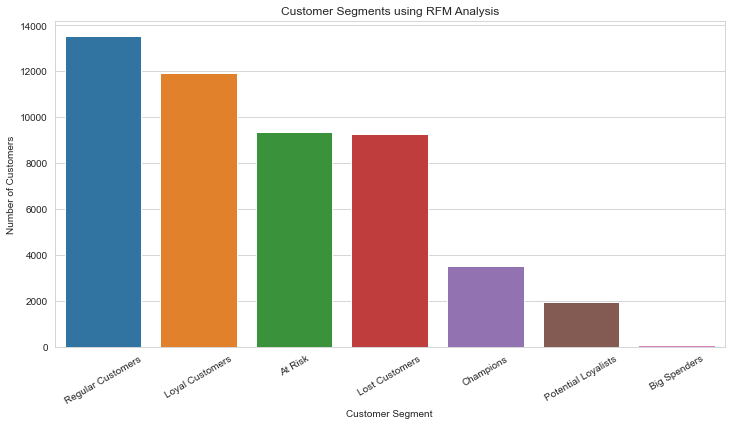

In [42]:
plt.figure(figsize=(12,6))

segment_counts = rfm["Segment"].value_counts()

sns.barplot(
    x=segment_counts.index,
    y=segment_counts.values
)

plt.title("Customer Segments using RFM Analysis")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30)

plt.show()

### Observation

The bar chart shows the number of customers in each RFM segment.

The **Regular Customers** segment contains the largest number of customers, while **Champions** represent the most valuable customers. The presence of **At Risk** and **Lost Customers** indicates opportunities for customer retention campaigns.

## 5.11 Percentage Distribution of Customer Segments

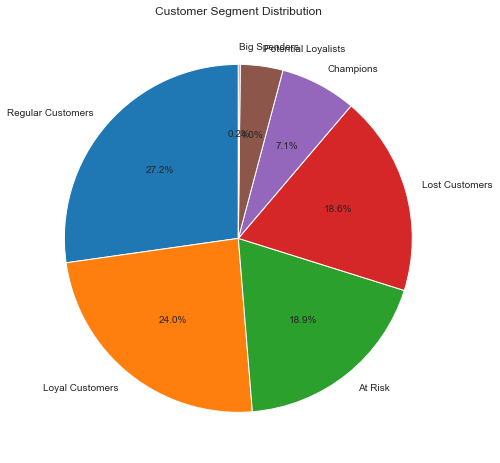

In [43]:
plt.figure(figsize=(8,8))

rfm["Segment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")

plt.title("Customer Segment Distribution")

plt.show()

### Observation

The pie chart illustrates the proportion of customers in each segment.

This visualization helps understand how customers are distributed across different business categories and supports decision-making for targeted marketing strategies.

## 5.12 Average RFM Values by Customer Segment

In [44]:
rfm.groupby("Segment")[["Recency","Frequency","Monetary"]].mean().round(2)

,Recency,Frequency,Monetary
Segment,,,
At Risk,345.95,6.44,17572.06
Big Spenders,261.94,4.87,19132.89
Champions,35.40,8.43,24147.47
Lost Customers,649.95,2.91,7950.54
Loyal Customers,91.74,6.52,17369.03
Potential Loyalists,86.48,4.44,15243.64
Regular Customers,170.86,3.41,8806.82


### Observation

The summary table compares the average Recency, Frequency, and Monetary values for each customer segment.

It confirms that Champions have high purchase frequency and spending, while At Risk and Lost Customers have not purchased recently.

# 6. Export Customer Segments

In [45]:
rfm.to_csv("customer_segments.csv", index=True)

print("Customer segments exported successfully!")

Customer segments exported successfully!


In [46]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'Customer Behaviour Analysis Report.pdf', 'Customer_Behavior_Analysis_Final.ipynb', 'customer_segments.csv', 'ecommerce_customer_data_large.csv']


# 7. Key Findings

Based on the analysis of customer purchasing behavior, the following key findings were observed:

1. The dataset contains **250,000 transaction records** from approximately **50,000 unique customers**.

2. Customers purchased products from multiple categories, indicating a diverse range of shopping preferences.

3. Revenue varies across product categories, suggesting that some categories contribute more to overall business sales.

4. Customers use different payment methods such as Credit Card, Debit Card, Cash, and PayPal, showing multiple payment preferences.

5. Purchase activity changes across different months, indicating seasonal buying patterns.

6. RFM Analysis successfully segmented customers into meaningful business groups such as:
   - Champions
   - Loyal Customers
   - Potential Loyalists
   - Regular Customers
   - Frequent Buyers
   - Big Spenders
   - At Risk Customers
   - Lost Customers

7. The majority of customers belong to the Regular Customers segment, while a smaller number are classified as Champions.

8. The presence of At Risk and Lost Customers highlights opportunities for customer retention and re-engagement strategies.

# 8. Recommendations

Based on the customer behavior analysis, the following recommendations are suggested for **Alfido Tech**:

### 1. Reward High-Value Customers

Provide loyalty rewards, exclusive discounts, and early access to new products for Champions and Loyal Customers to increase retention.

### 2. Re-engage At-Risk Customers

Send personalized emails, discount coupons, and reminder notifications to customers who have not purchased recently.

### 3. Promote High-Revenue Product Categories

Invest more marketing efforts in product categories that generate the highest revenue while improving visibility of lower-performing categories.

### 4. Personalize Marketing Campaigns

Use customer segmentation to recommend products based on purchase history, spending behavior, and customer preferences.

### 5. Improve Customer Retention

Monitor customer purchasing behavior regularly and identify customers who show declining purchase activity before they become inactive.

# 9. Conclusion

This project successfully analyzed customer purchasing behavior using Python, Pandas, Matplotlib, and Seaborn.

The dataset was cleaned and transformed through feature engineering to prepare it for analysis. Exploratory Data Analysis (EDA) helped identify purchasing trends, customer demographics, payment preferences, and revenue patterns.

RFM Analysis was used to segment customers into meaningful business groups based on Recency, Frequency, and Monetary values. These customer segments provide valuable insights for targeted marketing, customer retention, and business growth.

Overall, the analysis demonstrates how data-driven decision-making can help organizations improve customer engagement, increase sales, and strengthen long-term customer relationships.

In [47]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'Customer Behaviour Analysis Report.pdf', 'Customer_Behavior_Analysis_Final.ipynb', 'customer_segments.csv', 'ecommerce_customer_data_large.csv']


In [1]:
import os

print(os.getcwd())

C:\Users\hp\D\Interspark-Internship\Customer_Behavior_Analysis
